In [1]:
from netCDF4 import Dataset
import numpy as np
from datetime import date, timedelta, datetime
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr


***MLS***

In [ ]:
years = [str(year) for year in np.arange(2004,2015,1)]

full_water=[]
full_time=[]

for year in years:
    for file_path in glob.glob(f"/home/karengarcia/downloads-karengarcia/MLS_data/*{year}.nc"):
        with Dataset(file_path, 'r') as ds:
            
            data =      ds.groups['H2O PressureGrid'] 
            lon =       data.variables['lon'][:]             #units = "degrees_east" (72 values)
            lat =       data.variables['lat'][:]             #units = "degrees_north" (45 values)
            time =      data.variables['time'][:]            #units = "days since 1950-01-01" (12 values)
            water =     data.variables["value"][:]           #value(time, lev, lon, lat)
            pres =      data.variables["lev"][:]             #units = "hPa" (values 45) Pressure

            # changing time from dates into date times because it hates me apparently
            dates = []
            start = date(1950,1,1) #starting date
            for t in time:  
                delta = timedelta(days=float(t))
                dates.append(start + delta)
            full_water.append(water)  #making an array with all the time values in datetime
            full_time.append(dates)

**Legend** 

Dimension 1: Year

Dimension 2: Month

Dimension 3: Pressure 

Dimension 4: Longitude

Dimension 5: Latitude 

In [ ]:
time_flat = np.concatenate(full_time, axis=0)
water_flat = np.concatenate(full_water, axis=0)  # shape: (total_time, lev, lon, lat)
# print(np.shape(water_all))
lat_indices = np.where((lat >= -10) & (lat <= 10))[0]

zonal_avg = np.mean(np.mean(water_flat[:, :, :, lat_indices], axis=-1), axis=-1)  # shape: (time, lev)
print(np.shape(zonal_avg)) #should be (132,55)  
    

(132, 55)


Text(0.5, 1.0, 'Zonal Mean between 10S and 10 N MLS Water Vapour')

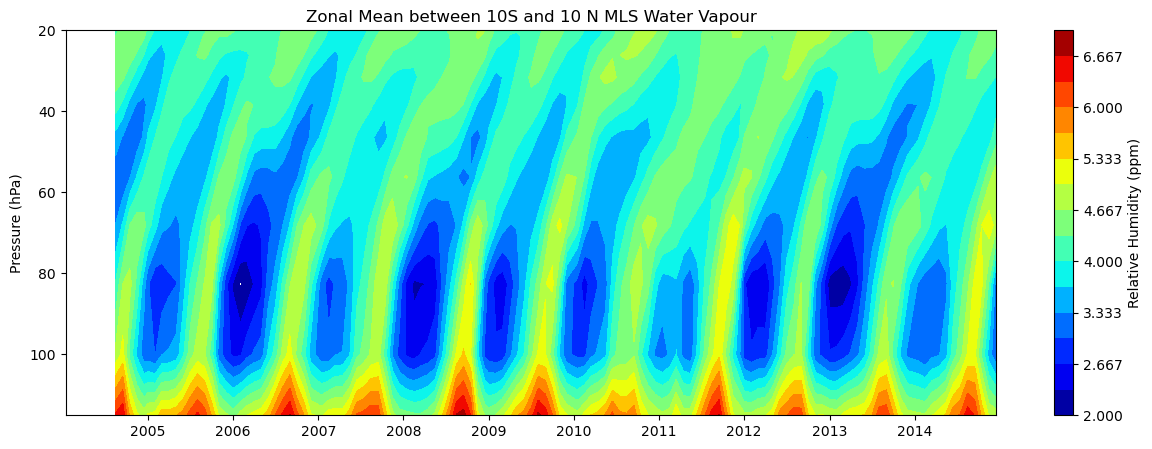

In [4]:
plt.figure(figsize=(15, 5))
cf = plt.contourf(time_flat, pres, zonal_avg.T*1000000, np.arange(2, 7, 0.33333333333), cmap = 'jet')
plt.ylim([20,115]) 
plt.colorbar(cf, label='Relative Humidity (ppm)', )

plt.ylabel("Pressure (hPa)")
plt.xlim([date(2004, 1, 15),date(2014, 12, 15)])

# Invert y-axis so pressure decreases upward
plt.gca().invert_yaxis()
plt.title("Zonal Mean between 10S and 10 N MLS Water Vapour")

***CanESM5 and CanESM5.1 Relative Humidity***

In [64]:
import cftime
max_lat = 10
min_lat = -10 
num_years = 11
with xr.open_dataset('/home/karengarcia/downloads-karengarcia/ESGF_downloads/hur_Amon_CanESM5_historical_r1i1p2f1_gn_185001-201412.nc') as ds:
    # display(ds)
    
    #slicing the data the last 11 years and also only between 10S and 10N 
    ds5 = (ds.isel(time=range(1980-(12*num_years),1980))).sel(lat=slice(min_lat, max_lat)) 

    #taking the mean value along lat and lon
    ds5 = ds5.mean(dim=['lat', 'lon'])

    #changing time to float because I can't plot datetime points
    units = 'days since 1850-01-01 0:0:0.0'
    Can5time = cftime.date2num(ds5['time'], units=units, calendar='noleap')
    # print(len(Can5time))
    # print(np.shape(ds5['hur']))

with xr.open_dataset('/home/karengarcia/downloads-karengarcia/ESGF_downloads/hur_Amon_CanESM5-1_historical_r1i1p2f1_gn_185001-201412.nc') as ds:
    ds51 = (ds.isel(time=range(1980-(12*num_years),1980))).sel(lat=slice(min_lat, max_lat))

    # #taking the mean value along lat and lon
    ds51 = ds51.mean(dim=['lat', 'lon'])

    #changing time to float because I can't plot datetime points
    units = 'days since 1850-01-01 0:0:0.0'
    Can51time = cftime.date2num(ds51['time'], units=units, calendar='noleap')

**Plotting**

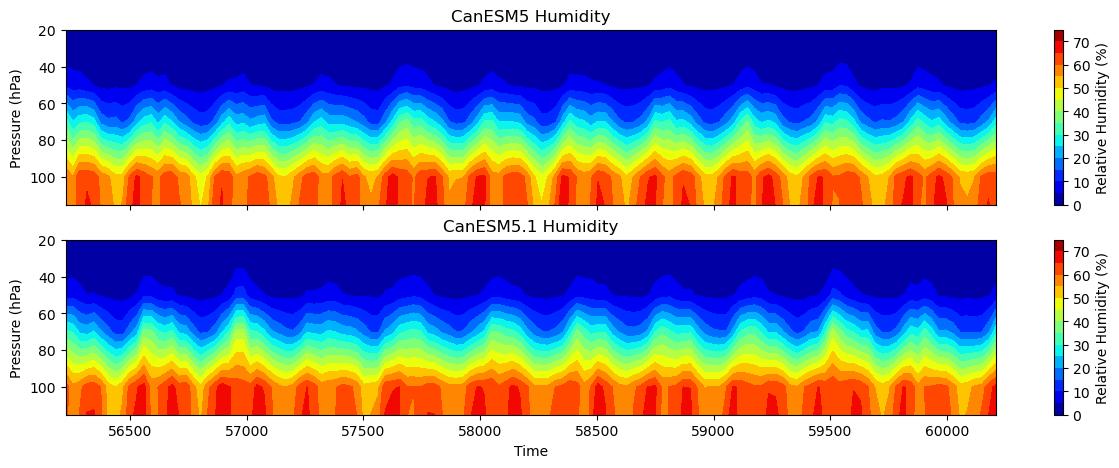

In [65]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True,sharex=True,figsize=(15, 5))
#     # fig, ax = plt.subplots(figsize=(15, 5))
cf1=ax1.contourf(Can5time, ds5["plev"]/100, ds5["hur"].T, np.arange(0, 80, 5), cmap="jet")
cf2=ax2.contourf(Can51time, ds51["plev"]/100, ds51["hur"].T, np.arange(0, 80, 5), cmap="jet")
# Invert y-axis (pressure levels usually decrease with height)
ax1.invert_yaxis()
ax2.invert_yaxis()

# Set y-axis limits for both subplots
ax1.set_ylim(115, 20)  # equivalent to invert_yaxis + ylim([20,115])
ax2.set_ylim(115, 20)

# Optional: labels
ax1.set_title("CanESM5 Humidity")
ax2.set_title("CanESM5.1 Humidity")
ax2.set_xlabel("Time")
ax1.set_ylabel("Pressure (hPa)")
ax2.set_ylabel("Pressure (hPa)")

cbar1 = fig.colorbar(cf1, ax=ax1)
cbar1.set_label("Relative Humidity (%)")
cbar2 = fig.colorbar(cf2, ax=ax2)
cbar2.set_label("Relative Humidity (%)")

# plt.tight_layout()
plt.show()